## Setup

### Import Libraries

In [1]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import numpy as np
from torch import optim

### Generate Data

Text(0, 0.5, 'y')

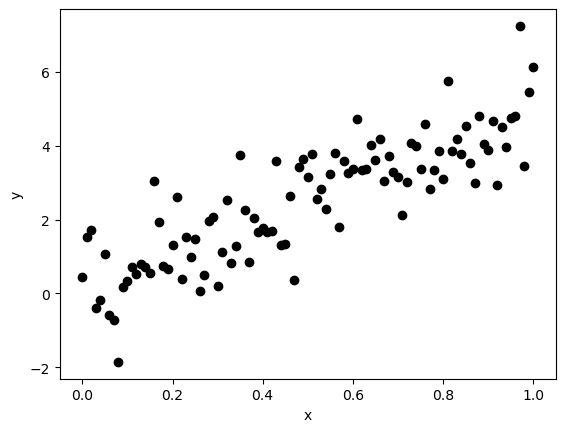

In [2]:
x = torch.linspace(0,1,101).unsqueeze(1)

y_obs = 5*x + torch.randn_like(x)

plt.plot(x, y_obs, 'o', color='black')
plt.xlabel("x")
plt.ylabel("y")

## Section 1: Creating a Model and Calculate the Prediction Loss

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `model(X_input)` | Pass input `X_input` to a neuronal network `model`. |
| `y_pred = model(X_input)` | Pass input `X_input` to a neuronal network `model` and assign the output to a variable `y_pred`. |
| `(y_pred-y_obs).square().mean()` | Calculate the mean squared error of the model prediction `y_pred` compared to the observed data `y_obs`. |
| `loss_function = nn.MSELoss()` | Creates a mean squared error (MSE) loss function and assigns it to a variable named `loss_function`. |
| `loss_function(y_pred, y_obs)` | Calculates the loss between the output of the network `y_pred` and the observed y-values from the data `y_obs`. |
| `loss_function(y_pred, y_obs).item()` | Extracts the loss value - i.e. the number alone as a ``float`` and not as a ``tensor``. |

**Demo**: Run the cell below to see a demonstration of how pytorch can be used to do linear regression. We'll learn how to do each of these steps in the following sections.

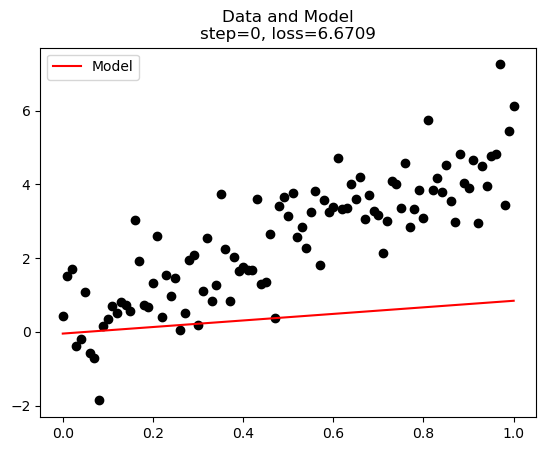

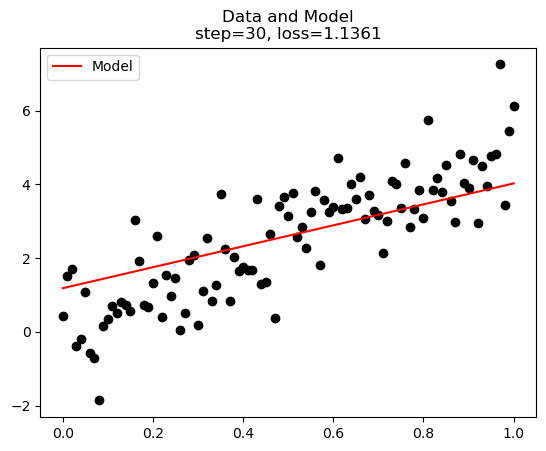

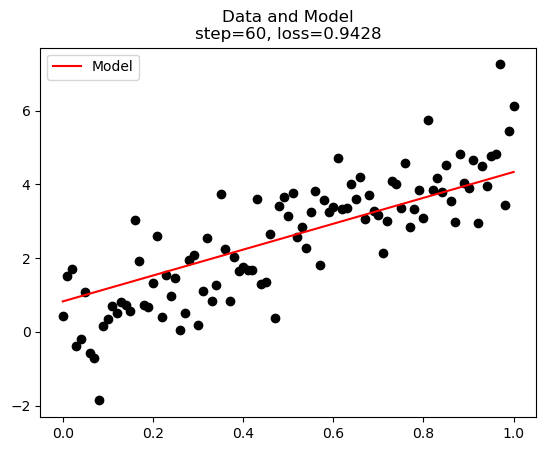

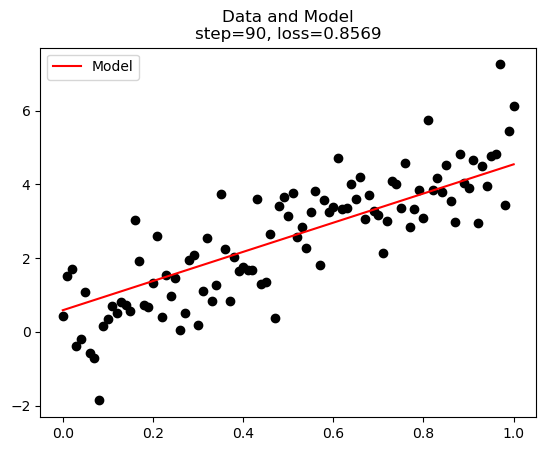

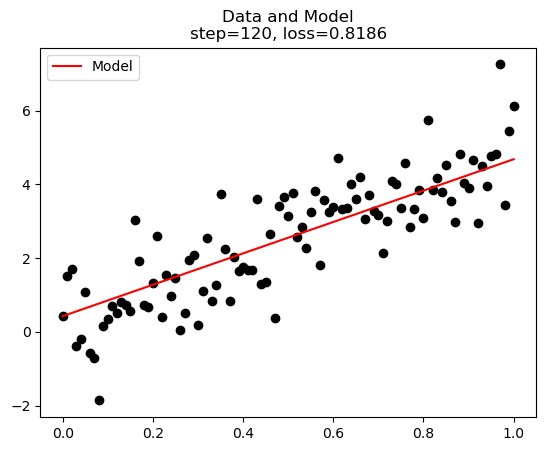

In [ ]:
# create model
model = nn.Linear(1,1)

# create optimizer
optimizer = optim.SGD(model.parameters(), lr=0.1)

# optimize model through iterative guessing and parameter updates
for step in range(121):
    # reset gradients
    optimizer.zero_grad()

    # predict output with model
    y_pred = model(x)

    # calculate prediction loss
    loss = (y_pred-y_obs).square().mean()

    # plot the data and the model
    if (step % 30) == 0:
        plt.figure()
        plt.title(f"Data and Model\nstep={step}, loss={loss:.4f}")
        plt.plot(x, y_obs, "o", color="black")
        plt.plot(x, model.weight.item()*x + model.bias.item(), color="r", label="Model")
        #plt.plot(x, y_pred.detach().numpy())
        plt.legend()

    # do backpropagation to get gradients
    loss.backward()

    # update model parameters
    optimizer.step()

**Example**: Create a single layer model with 2 input features and 16 output features.

In [62]:
nn.Linear(2, 16)

Linear(in_features=2, out_features=16, bias=True)

**Exercise**: Create a single layer model with 1 input feature and 8 output features.


In [63]:
nn.Linear(1,8)

Linear(in_features=1, out_features=8, bias=True)

**Exercise**: Create a single layer model with 20 input feature and 2 output features and assign it to a variable called `model`. Print the `model` variable.


In [64]:
model = nn.Linear(20,8)
print(model)

Linear(in_features=20, out_features=8, bias=True)


**Exercise**: Pass the random input generated below to the model.

The output from the model should look like this:

`tensor([-0.5226,  1.6793, -0.3106,  0.6826,  0.0241,  0.1157,  0.5314, -0.3382],
       grad_fn=<ViewBackward0>)`

In [21]:
torch.manual_seed(2025)
input = torch.randn(20)
input

tensor([-1.1607, -1.5591,  0.7782, -0.9990,  0.4670,  1.1802,  0.3709, -2.0193,
        -1.1871, -0.2822, -0.2651,  2.7671, -1.1414,  0.3533, -0.0972, -0.1674,
         0.9320, -0.7882, -2.8070,  0.5447])

In [22]:
model(input)

tensor([ 0.2450, -0.1548,  0.0408, -0.1472,  0.7695, -0.3531, -0.5432,  0.8459],
       grad_fn=<ViewBackward0>)

**Exercise**: Run the cell below to generate a new random input. Try to pass this input to the model. What does the error message you get say?

In [66]:
torch.manual_seed(2025)
input = torch.randn(25)
input

tensor([-1.1607, -1.5591,  0.7782, -0.9990, -0.3729, -0.1594,  0.2836, -1.1234,
         0.9813, -0.2822, -0.2651,  2.7671,  0.8749, -0.1597, -1.5970, -0.7229,
        -0.8230, -0.7882, -2.8070,  0.5447, -1.6047,  0.2632, -1.9616, -0.9576,
        -0.5698])

In [67]:
model(input)

tensor([ 0.3432, -0.5181,  0.6703,  0.3846, -0.6244,  0.4713, -0.2647, -0.0117],
       grad_fn=<ViewBackward0>)

Presumably, you got the following error message: "RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x25 and 20x8)".

You got this error because the dimensions of the input (1x25) don't match the number of input features in the model (which is 20).

The error message also reveals an important fact about passing inputs through a neural network model: It's a matrix multiplication! And when you do matrix multiplication, the dimensions of the matrices (along which the multiplication is carried out) have to match. To fix the issue above, you can create a new model with 25 input features.

**Exercise**: Create a single layer with 25 input features and 2 output features and assign it to a variable called `model`. Then pass the same random input to the model as in the previous exercise. Did it run through now?

In [68]:
model = nn.Linear(25,8)
model(input)

tensor([-1.1816, -0.2168, -0.4422, -0.1845,  0.3989, -0.8125, -0.1305,  0.0673],
       grad_fn=<ViewBackward0>)

In the cell below a very simple model with a single input and output feature is created. Then, the `x` data generated in the setup section is passed to it.

**Exercise**: Calculate the mean square error of the model prediction `y_pred` (compare to the observed data `y_obs`). This is the prediction loss.

**Hint**: See reference table. 

The output should look like this:

`tensor(4.6639, grad_fn=<MeanBackward0>)`

In [69]:
torch.manual_seed(2025)

model = nn.Linear(1,1)
y_pred = model(x)

In [70]:
(y_pred-y_obs).square().mean()

tensor(4.6724, grad_fn=<MeanBackward0>)

**Exercise**: Create a loss function using `torch`'s function `nn.MSELoss()` and assign it to a variable named `loss_function`.

In [98]:
loss_function = nn.MSELoss()

**Exercise**: Calculate the same mean square error loss of the prediction `y_pred` using the loss function you created in the previous exercise.

In [99]:
loss_function(y_pred, y_obs)

tensor(4.6639, grad_fn=<MseLossBackward0>)

**Exercise**: Extract the number from the loss you calculated in the previous exercise from the tensor.

**Hint**: `.item()`

In [101]:
loss_function(y_pred, y_obs).item()

4.663857460021973

## Section 2: Optimize Model Parameters

We have gone through how to create a model, pass input to it to get a prediction, and calculate the loss (error) of the prediction. The next step is to optimize the parameters of the model based on that loss. In the previous session, we did implemented the optimization method called gradient descent ourselves. However, PyTorch provides a package called `optim` that can be used to create optimizer objects that different kinds of optimization methods for us.

**Standard gradient descent**

$$
w_{t+1} = w_{t} - \eta \nabla L(w)
$$

for parameter i at time step (epoch) t, where L is loss function to be minimized.

Written differently:

$$
w_{t+1} = w_{t} - \eta \frac{1}{N}\sum_{j}^{N}\nabla l(y_{j}, f_{w}(x_{j}))
$$

**Stochastic gradient descent**

Divide data into batches compute gradient for each seperately:

$$
w_{t+1} = w_{t}- \eta \frac{1}{|B_{t}|}\sum_{j}^{B_{t}}\nabla l(y_{j}, f_{w}(x_{j}))
$$

The subset (batch) B_{t} is different at each training step (epoch) t.


| Code | Description |
| --- | --- |
| `optim.SGD(model.parameters())` | Creates a stochastic gradient descent (SGD) optimizer. |
| `optim.SGD(model.parameters(), lr=0.01, momentum = 0.99)` | Creates a stochastic gradient descent (SGD) optimizer with a learning rate `lr` of 0.01 (the default value is 0.001) and ``momentum`` of 0.99 (the default value is 0.9). |
| `optimizer.zero_grad()` | Resets the gradients before the next iteration in the optimization. |
| `loss.backward()`| Performs backward propagation and calculates the gradients through the graph leaves (network). |
| `optimizer.step()` | Update the parameters of the network. |
| `for epoch in range(10):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(epoch)` | Print every number `epoch` between 0 and 10 (not including 5)|

**Example**: Create a stochastic gradient descent optimizer for the model defined in the cell below. Assign it to a variable named `optimizer`.

In [164]:
torch.manual_seed(2025)
model = nn.Linear(1,1)

Run the cell below that gets the `weight` parameter of the model.

In [165]:
model.weight

Parameter containing:
tensor([[0.3699]], requires_grad=True)

In [166]:
optimizer = optim.SGD(model.parameters())

**Exercise**: Create a stochastic gradient descent optimizer with a learning rate of `0.1` for the same model. Assign it to a variable named `optimizer`.

In [167]:
optimizer = optim.SGD(model.parameters(), lr=0.1)

Run the cell below to pass the input to the model, create an MSE loss function, and calculate the loss of the model prediction.

**Exercise**: Do backpropagation on the loss.

In [168]:
# pass input to model
y_pred = model(x)

# create a loss function
loss_function = nn.MSELoss()

# calculate loss of 
loss = loss_function(y_pred, y_obs)
loss

tensor(4.6724, grad_fn=<MseLossBackward0>)

In [169]:
loss.backward()

**Exercise**: Now that the gradients have been calculated, you can update the model parameters using the `.step()` function of the `optimizer`. After updating the parameters, run the cell below that gets the `weight` parameter of the model. Is it different from the initial `weight` parameter displayed at the beginning of the section?

In [170]:
optimizer.step()

In [171]:
model.weight

Parameter containing:
tensor([[0.5937]], requires_grad=True)

Run the cell below that gets the gradient of the weight parameter.

In [172]:
model.weight.grad

tensor([[-2.2377]])

**Exercise**: Reset the gradients of model with the optimizer. Then, run the cell below that gets the gradient of the weight parameter again. This time, nothing will be displayed (if you solved this exercise correctly). Why is that, do you think?

In [173]:
optimizer.zero_grad()

Run the cell below that gets the gradient of the weight parameter. This time, nothing will be displayed (if you solved this exercise correctly). Why is that, do you think?

In [174]:
model.weight.grad

**Exercise**: Put the following code in a loop of 5 epochs.

In [177]:
# reset the gradients
optimizer.zero_grad()

# pass the input to the network
y_model = model(x)

# calculate the loss
loss = loss_function(y_model, y_obs)

# perform backward propagation to calculate the gradients
loss.backward()

# update the parameters
optimizer.step()

print(f"loss = {loss.item()}")

loss = 1.716313123703003


In [178]:
for epoch in range(5):
    # reset the gradients
    optimizer.zero_grad()
    
    # pass the input to the network
    y_model = model(x)

    # calculate the loss
    loss = loss_function(y_model, y_obs)

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters
    optimizer.step()

    print(f"loss = {loss.item()}")

loss = 1.6898225545883179
loss = 1.6648187637329102
loss = 1.6409164667129517
loss = 1.6178932189941406
loss = 1.5956183671951294


## Section 3: Evaluate Model Performance

| Code | Description |
| --- | --- |
| `new_list = []` or `new_list = list()`| Initialize an empty list named `new_list` |
| `new_list.append(element)`| Append an element to the list `new_list` |
| `plt.plot(a, b)`| Plot the elements of `a` against the elements of `b`. |

The output of the network is a score for each class that reflects the networks belief that a data point corresponds to a given class. This is not the same as a class label. To get the output in the form of a class guess by the network, we have to determine which class the network thinks that a data point is most likely to belong to using the output scores.

| Code | Description |
| --- | --- |
| `torch.argmax(x, dim=1)` | Finds the index at which the tensor `x` has the highest value along its first dimension. |
| `a == b` | Compares each element of the tensors (or arrays) `a` and `b` and returns a tensor of boolean (`True` or `False`) values indicating which elements are the same (`True`) and different (`False`). |
| `(a == b).sum()` or `torch.sum(a == b)`| Sums all elements where the condition `a == b` is `True`. `True` is counted as 1, `False` as 0. |
| `(a == b).sum() / len(a)` | Calculates proportion of elements in `a` where the element is equal to the corresponding element in `b`.|

Run the cell below to create a network, select a subset of the data, and pass this subset through the network to get an output `y_net`.

## Leftovers

## Section 1: Create a Model

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `model(X_input)` | Pass input `X_input` to a neural network named `model`. |
| `y_model = model(X_input)` | Pass input `X_input` to a neural network `model` and assign the output to a variable `y_model`. |
| `nn.ReLU()` | Create a rectified linear unit activation function.|
| `nn.Tanh()` | Create a hyperbolic tangent activation function.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;` nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;` nn.Linear(10,1)`<br>`)` | Creates a container where layers and activation functions are stacked in a sequential order. This ensures that the input is passed through the network in specific order.|

**Exercise**: Create a rectified linear unit activation function.

In [ ]:
model = nn.ReLU()

**Exercise**: Create a hyperbolic tangent activation function.

In [ ]:
nn.Tanh()

**Exercise**: Create a sequence of layers with a rectified linear unit between them. The first layer should have two input features and 16 output features, the last layer should take in the 16 outputs from the first layer and output two features.
When you display it, the output should look like this:

Sequential(  <br>
  &nbsp;&nbsp;(0): Linear(in_features=2, out_features=16, bias=True)  <br>
  &nbsp;&nbsp;(1): ReLU()  <br>
  &nbsp;&nbsp;(2): Linear(in_features=16, out_features=2, bias=True)  <br>
)

**Hint**: nn.Sequential (see reference table).

In [ ]:
nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,2)
)

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=2, bias=True)
)

**Exercise**: Create sequence of three linear layers with one hyperbolic tangent activation function and one rectified linear unit between the first and the second linear layer, respectively. The first layer should have two input features and 32 output features, the next linear layer should have 32 input features and 32 output features, the last layer should take in the 32 outputs from the previous layer and output two features.
When you display it, the output should look like this:

Sequential(  <br>
  &nbsp;&nbsp;(0): Linear(in_features=2, out_features=32, bias=True)  <br>
  &nbsp;&nbsp;(1): Tanh()  <br>
  &nbsp;&nbsp;(0): Linear(in_features=32, out_features=32, bias=True)  <br>
  &nbsp;&nbsp;(1): ReLU()  <br>
  &nbsp;&nbsp;(2): Linear(in_features=32, out_features=2, bias=True)  <br>
)

**Hint**: nn.Sequential (see reference table).

In [ ]:
nn.Sequential(
    nn.Linear(2,32),
    nn.Tanh(),
    nn.Linear(32,32),
    nn.ReLU(),
    nn.Linear(16,2)
)

Sequential(
  (0): Linear(in_features=2, out_features=32, bias=True)
  (1): Tanh()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=2, bias=True)
)